**OPTIONS PRICING MODEL**

**In this project, we will :**

-Use Black-Scholes method to ***price european options (call options)***

-Compute the ***Implied Volatilities*** using Black-Scholes and Newton methods

-Fetch options data from yahoo Finance

-Compare both the implied volatilities and the BS prices to the market implied volatilities and option prices

-Plot the ***Implied volatility skew***

*Black-Scholes Model*


In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from jax.scipy.stats import norm
import pandas as pd

In [2]:
stock_data = yf.download ('MSFT', '2019-01-01', '2021-01-01')
stock_data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2019-01-02,94.397148,94.985261,92.362083,92.931528,35329300
2019-01-03,90.924492,93.529003,90.737784,93.444983,42579100
2019-01-04,95.153297,95.694738,92.352749,93.090228,44060600
2019-01-07,95.274658,96.404212,94.266466,94.882583,35656100
2019-01-08,95.965462,97.057674,94.947925,96.189504,31514400
...,...,...,...,...,...
2020-12-24,213.250748,214.074073,211.766845,211.977464,10550600
2020-12-28,215.366470,216.390832,213.509200,214.878210,17933500


In [2]:
#Pour rendre les calculs faciles et rapides (notamment celui du gradient), on va travailler avec la librairie jax
#!pip install jax
import jax
import jax.numpy as jnp
from jax import grad

In [3]:
class BlackScholes:
    def __init__(self,spot, strike, rate, div, sigma,T ):
        self.K = strike
        self.S =spot
        self.r = rate #risk-free rate
        self.sigma = sigma # implied volatility of the underlying stock 
        self.q = div
        self.T = T #expiration of the contract
    def call_price(self): 
        d1 =  (jnp.log(self.S/self.K) + (self.r - self.q +0.5*self.sigma**2)*self.T)/(self.sigma*jnp.sqrt(self.T))
        d2 = d1 - self.sigma*jnp.sqrt(self.T)
        CallPrice = self.S*jnp.exp(-self.q*self.T)*norm.cdf(d1, 0, 1) - self.K*jnp.exp(-self.r*self.T)*norm.cdf(d2, 0, 1)
        return (CallPrice)

        
T = 20/52
myoption = BlackScholes(49,50,0.05,0,0.2,T)
price = myoption.call_price()
print (price)
        

2.400528


***IMPLIED VOLATILITY BS***

In [24]:
#Calcul de vol implicite de l'option : Méthode de Newton
def implied_vol(S, K,sigma_guess,r, q,T,mkt_price, N_iter= 10, eps=1e-4):
    """calcul de la vol implicite avec la méthode de newton"""
    
    def price_diff (sigma): 
        myoption = BlackScholes(S,K,r,q,sigma,T)
        priceBS = myoption.call_price ()
        return(priceBS - mkt_price)
        
    sigma = sigma_guess
    loss_grad = grad(price_diff)

    for _ in range (N_iter):
        loss = price_diff(sigma)
        if abs(float(loss))<eps: 
            break
        vega = loss_grad(sigma)
        if abs(float(vega))<1e-8: 
            break
        sigma = sigma - loss/vega
        sigma = jnp.maximum(sigma, 1e-6) #on s'assure que la vol ne devient pas négative
    return float(sigma)
#call_option = BlackScholes(49,50,0.05,0,0.2,20/52)
#call_option.call_price()
mkt_price = 2.400053

sigma = implied_vol(S= 49,K = 50,sigma_guess = 0.03, r= 0.05, q = 0,T= 20/52, mkt_price = 2.400053, N_iter= 5)
sigma


0.19996093213558197

***Fetching Options data***

In [26]:
def fetch_option_data (ticker_symbol): 
    """Fetching options data for a given ticker symbol"""
    ticker = yf.Ticker (ticker_symbol)
    try: 
        info= ticker.info  #info is a dictionary 

        if not info: 
            print("Ticker not found, please enter a valid ticker_symbol")
            return None
        else: 
            options_dates = ticker.options
            options_data = ticker.option_chain(options_dates[-3]) 
            return options_data.calls#, options_data.puts
    except Exception as e:
        print (f"Erreur: {e}")
df= fetch_option_data("AAPL")
df.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,AAPL280121C00005000,2026-03-24 15:13:05+00:00,5.0,248.50,247.0,252.0,0.0,0.0,38.0,59,2.161137,True,REGULAR,USD
1,AAPL280121C00010000,2026-03-26 13:58:07+00:00,10.0,243.39,242.0,247.0,0.0,0.0,1.0,26,1.595217,True,REGULAR,USD
2,AAPL280121C00015000,2026-02-19 20:28:14+00:00,15.0,245.12,237.0,242.0,0.0,0.0,1.0,9,1.339847,True,REGULAR,USD
3,AAPL280121C00020000,2026-02-06 20:53:05+00:00,20.0,258.54,228.0,233.0,0.0,0.0,3.0,10,0.000010,True,REGULAR,USD
4,AAPL280121C00025000,2026-02-02 14:55:08+00:00,25.0,238.42,223.5,228.5,0.0,0.0,2.0,4,0.000010,True,REGULAR,USD


In [6]:
spot_Apple =yf.Ticker("AAPL").history()['Close'].iloc[-1]
spot_Apple

254.57000732421875

***Extracting Inputs for the BS Model***

In [19]:
ticker = yf.Ticker("AAPL")
div =ticker.info.get('dividendYield', 0.0)/100 or 0.0 #taux de dividende de l'action

#Il nous faut également le prix du sous-jacent (le spot)
Spot = ticker.history(period= "1d")['Close']
S = Spot.item()

#On va maintenant extraire le taux sans risque (taux d'une obligation du trésor)
treasury = yf.Ticker("^FVX")
data = treasury.history(period ='1d')
rate = data['Close'].item()/100 #risk-free rate en %
print (S,rate, div)

254.5399932861328 0.03947999954223633 0.0040999999999999995


In [27]:
#Ici nous allons extraire la date d'expiration de l'option et le nombre d'années qu'il reste jusqu'à expiration
def expiration (contract_symbol,n):
    """Compute the expiration time from the dataset for a given contract"""
    #n =len of the ticker_symbol
    date = contract_symbol[n:n+6]
    year= 2000 + int(date[0:2])
    month = int(date[2:4])
    days = int(date[4:6])

    expiration_date = datetime (year, month, days)

    valuation_date = datetime.now() #we take the current date as the valuation date

    T = (expiration_date - valuation_date).days/365 #annualized value
    
    return T

In [16]:
t1= datetime.now()
t2 = datetime (2027,1,15)
T = (t2 - t1).days/365
T

0.7890410958904109

In [28]:
df['BSPrice'] =df.apply(lambda row: BlackScholes(
    spot = S,
    strike = row['strike'],
    rate= rate, 
    div= div, 
    sigma = row['impliedVolatility'], 
    T = expiration (row['contractSymbol'], n=4)).call_price(),axis = 1)
df.sort_values("volume", ascending= False)

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,BSPrice
42,AAPL280121C00300000,2026-04-01 17:20:56+00:00,300.0,28.95,28.40,29.25,0.450001,1.578950,119.0,5553,0.328773,False,REGULAR,USD,34.330772
43,AAPL280121C00310000,2026-04-01 17:20:45+00:00,310.0,25.55,24.80,25.95,0.429998,1.711777,84.0,973,0.323951,False,REGULAR,USD,30.75911
44,AAPL280121C00320000,2026-04-01 17:43:08+00:00,320.0,22.45,21.30,22.70,0.000000,0.000000,52.0,2612,0.317512,False,REGULAR,USD,27.220535
0,AAPL280121C00005000,2026-03-24 15:13:05+00:00,5.0,248.50,247.00,252.00,0.000000,0.000000,38.0,59,2.161137,True,REGULAR,USD,249.8838
65,AAPL280121C00530000,2026-03-31 18:17:05+00:00,530.0,1.47,1.40,1.65,0.000000,0.000000,32.0,2922,0.289497,False,REGULAR,USD,2.3512793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,AAPL280121C00185000,2026-04-01 18:26:06+00:00,185.0,92.35,91.05,93.90,3.470001,3.904142,1.0,477,0.446813,True,REGULAR,USD,99.76201
31,AAPL280121C00195000,2026-03-24 14:25:35+00:00,195.0,83.19,83.90,87.00,0.000000,0.000000,1.0,68,0.435659,True,REGULAR,USD,92.98211
7,AAPL280121C00040000,2026-03-13 16:45:41+00:00,40.0,213.29,214.00,219.00,0.000000,0.000000,1.0,15,0.786867,True,REGULAR,USD,216.69585
19,AAPL280121C00135000,2026-03-31 17:36:03+00:00,135.0,132.25,130.00,134.00,0.000000,0.000000,1.0,66,0.514897,True,REGULAR,USD,136.67297


In [29]:
df['Price_diff']= df['lastPrice']-df['BSPrice']
df.sort_values("volume", ascending=False)

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,BSPrice,Price_diff
42,AAPL280121C00300000,2026-04-01 17:20:56+00:00,300.0,28.95,28.40,29.25,0.450001,1.578950,119.0,5553,0.328773,False,REGULAR,USD,34.330772,-5.3807716
43,AAPL280121C00310000,2026-04-01 17:20:45+00:00,310.0,25.55,24.80,25.95,0.429998,1.711777,84.0,973,0.323951,False,REGULAR,USD,30.75911,-5.2091103
44,AAPL280121C00320000,2026-04-01 17:43:08+00:00,320.0,22.45,21.30,22.70,0.000000,0.000000,52.0,2612,0.317512,False,REGULAR,USD,27.220535,-4.7705345
0,AAPL280121C00005000,2026-03-24 15:13:05+00:00,5.0,248.50,247.00,252.00,0.000000,0.000000,38.0,59,2.161137,True,REGULAR,USD,249.8838,-1.3838043
65,AAPL280121C00530000,2026-03-31 18:17:05+00:00,530.0,1.47,1.40,1.65,0.000000,0.000000,32.0,2922,0.289497,False,REGULAR,USD,2.3512793,-0.88127923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,AAPL280121C00185000,2026-04-01 18:26:06+00:00,185.0,92.35,91.05,93.90,3.470001,3.904142,1.0,477,0.446813,True,REGULAR,USD,99.76201,-7.41201
31,AAPL280121C00195000,2026-03-24 14:25:35+00:00,195.0,83.19,83.90,87.00,0.000000,0.000000,1.0,68,0.435659,True,REGULAR,USD,92.98211,-9.792107
7,AAPL280121C00040000,2026-03-13 16:45:41+00:00,40.0,213.29,214.00,219.00,0.000000,0.000000,1.0,15,0.786867,True,REGULAR,USD,216.69585,-3.4058533
19,AAPL280121C00135000,2026-03-31 17:36:03+00:00,135.0,132.25,130.00,134.00,0.000000,0.000000,1.0,66,0.514897,True,REGULAR,USD,136.67297,-4.4229736


In [38]:
#coded for comparison purposes with the previous code

def prix (S,K,r,div,sigma, T):
    d1 = (jnp.log(S/K) +(r-div+sigma**2)*T)/(sigma*jnp.sqrt(T))
    d2 =d1 -sigma*jnp.sqrt(T)
    prix = S*jnp.exp(-div*T)*norm.cdf(d1,0,1) - K*jnp.exp(-r*T)*norm.cdf(d2,0,1)

    return prix
prix(S=248.8,
     K =5,
     r= 0.0407,
     div=0.0040999,
     sigma = 1.94336, 
     T = 294/365)
#248.8000030517578 0.04070000171661377 0.0040999999999999995

Array(243.19125, dtype=float32)

**Rajoutons les vols Implicites obtenues avec BS + Newton et comparons les à celles du marché**

In [31]:
df =df[df['contractSymbol'].notna()] #we drop the rows with missing values in the contract symbol column
df['IV_BS']= df.apply(lambda row: implied_vol(S=S, K=row['strike'],sigma_guess=0.3, r= rate, q= div,
                                 T = expiration(row['contractSymbol'],4),
                                 mkt_price=row['lastPrice'],N_iter=100, eps=1e-4), axis= 1)

df['IV_diff']= df['impliedVolatility'] - df['IV_BS']
df.sort_values("volume", ascending=False)

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,BSPrice,Price_diff,IV_BS,IV_diff
42,AAPL280121C00300000,2026-04-01 17:20:56+00:00,300.0,28.95,28.40,29.25,0.450001,1.578950,119.0,5553,0.328773,False,REGULAR,USD,34.330772,-5.3807716,2.890150e-01,3.975756e-02
43,AAPL280121C00310000,2026-04-01 17:20:45+00:00,310.0,25.55,24.80,25.95,0.429998,1.711777,84.0,973,0.323951,False,REGULAR,USD,30.75911,-5.2091103,2.851988e-01,3.875204e-02
44,AAPL280121C00320000,2026-04-01 17:43:08+00:00,320.0,22.45,21.30,22.70,0.000000,0.000000,52.0,2612,0.317512,False,REGULAR,USD,27.220535,-4.7705345,2.815019e-01,3.600979e-02
0,AAPL280121C00005000,2026-03-24 15:13:05+00:00,5.0,248.50,247.00,252.00,0.000000,0.000000,38.0,59,2.161137,True,REGULAR,USD,249.8838,-1.3838043,3.000000e-01,1.861137e+00
65,AAPL280121C00530000,2026-03-31 18:17:05+00:00,530.0,1.47,1.40,1.65,0.000000,0.000000,32.0,2922,0.289497,False,REGULAR,USD,2.3512793,-0.88127923,2.657888e-01,2.370809e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,AAPL280121C00185000,2026-04-01 18:26:06+00:00,185.0,92.35,91.05,93.90,3.470001,3.904142,1.0,477,0.446813,True,REGULAR,USD,99.76201,-7.41201,3.582326e-01,8.858075e-02
31,AAPL280121C00195000,2026-03-24 14:25:35+00:00,195.0,83.19,83.90,87.00,0.000000,0.000000,1.0,68,0.435659,True,REGULAR,USD,92.98211,-9.792107,3.267142e-01,1.089451e-01
7,AAPL280121C00040000,2026-03-13 16:45:41+00:00,40.0,213.29,214.00,219.00,0.000000,0.000000,1.0,15,0.786867,True,REGULAR,USD,216.69585,-3.4058533,1.000000e-06,7.868664e-01
19,AAPL280121C00135000,2026-03-31 17:36:03+00:00,135.0,132.25,130.00,134.00,0.000000,0.000000,1.0,66,0.514897,True,REGULAR,USD,136.67297,-4.4229736,4.248887e-01,9.000870e-02


***Implied Volatility Skew***

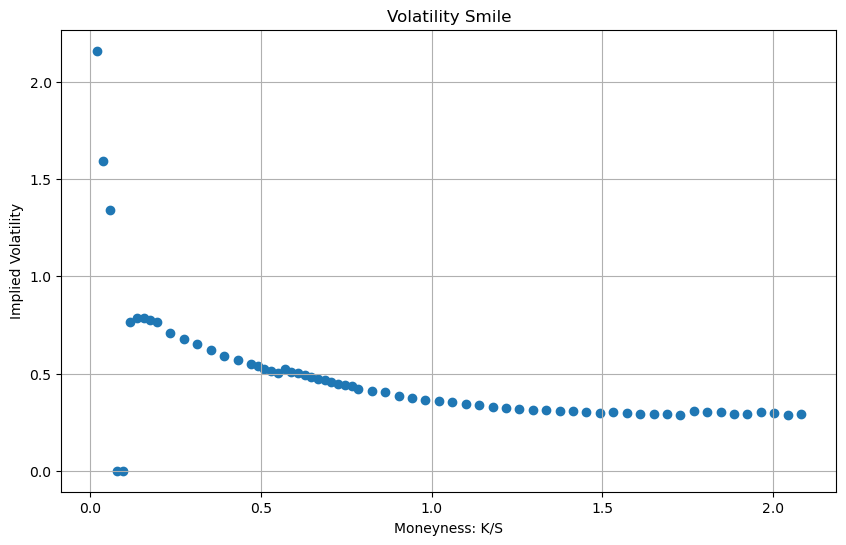

In [36]:
df_clean = df[
    (df['strike']>0) &
    (df['impliedVolatility']>0)
]

x = df_clean['moneyness'] = df_clean['strike']/S
y = df_clean['impliedVolatility']

plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.xlabel("Moneyness: K/S")
plt.ylabel("Implied Volatility")
#plt.axis([0,200, 0, 2])
plt.title("Volatility Smile")
plt.grid()
plt.show()